In [2]:
import pandas as pd
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

bids_folder = '/Users/mrenke/data/ds-stressrisk'
plot_folder_path = '/Users/mrenke/Desktop/StressRisk/figures/plots/paper'

sns.set_context('talk')
sns.set_theme('paper', 'white', font='helvetica', font_scale=2, palette='tab10')


In [4]:
from stress_risk.behavior.utils import get_data
df = get_data()
group_mapping = df.groupby(['subject', 'group']).size().reset_index(['group']).drop(0, axis=1)


# Methdos

## RNP & psychometric curve illustration

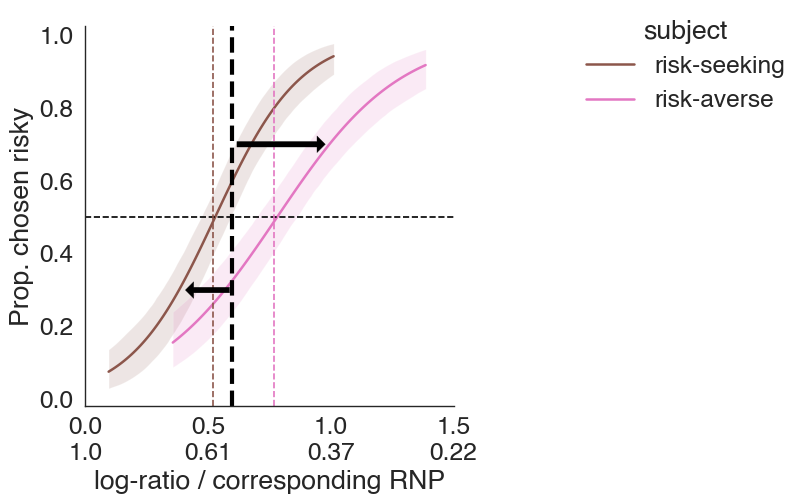

In [17]:
sns.set_theme('paper', 'white', font='helvetica', font_scale=2, palette='tab10')

d = df.loc[([1,4])] # subject = 1

fac = sns.lmplot(d.reset_index(), x = 'log(risky/safe)', y = 'chose_risky', hue= 'subject',  logistic= True,palette=sns.color_palette()[5:], scatter=False ) # col = 'subject', , legend_out=True

plt.axhline(.5, c='k', ls='--')
plt.axvline(np.log(1/0.55), c='k', ls='--', linewidth = 3)

xlbls1 = np.round(fac.ax.get_xticks(),2)
xlbls2 = np.round(np.exp(xlbls1),2)
xlbls3 = [np.round(1/item,2) for item in xlbls2]
xlbls = [str(a) + '\n' + str(c) for a, c in zip(xlbls1, xlbls3)]
fac.set_xticklabels(xlbls)

plt.axvline(.52, c=sns.color_palette()[5], ls='--')
plt.axvline(.77, c=sns.color_palette()[6], ls='--')

plt.ylabel('Prop. chosen risky')
plt.xlabel('log-ratio / corresponding RNP')

legend_labels = {"1": "risk-seeking", "4": "risk-averse"}
for t, l in zip(fac._legend.texts, legend_labels.values()):
    t.set_text(l)
sns.move_legend(fac, "upper left",bbox_to_anchor=(1,1))

y_arrow = 0.3
plt.annotate('', xytext=(np.log(1/0.55),y_arrow), xy=(np.log(1/0.55)-0.2,y_arrow), arrowprops={"color":'k', "linewidth":.2, 'shrink':0.05, 'headlength':6})
y_arrow = 0.7
plt.annotate('', xytext=(np.log(1/0.55),y_arrow), xy=(np.log(1/0.55)+ 0.4,y_arrow), arrowprops={"color":'k', "linewidth":.2, 'shrink':0.05, 'headlength':6})

plt.title('')
plt.savefig(op.join(plot_folder_path, f'psychometric-curve_rnp_illustration_02.pdf'), transparent=True)


## NLC model illustration

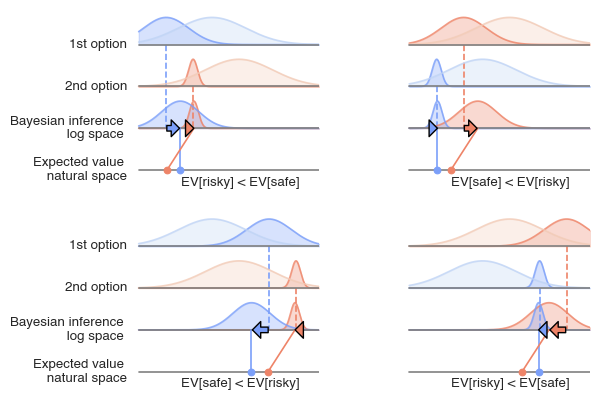

In [5]:

from utils import plot_bayesian_inference, annotat_bayesian_inference
import seaborn as sns 
import matplotlib.pyplot as plt

sns.set_theme('paper', 'white', font='helvetica', font_scale=1, palette='tab10')

plt.subplot(221)
plot_bayesian_inference(risky_first = False,base = 5)
annotat_bayesian_inference()
plt.subplot(222)
plot_bayesian_inference(risky_first = True,base = 5)
plt.subplot(223)
plot_bayesian_inference(risky_first = False,base = 49)
annotat_bayesian_inference()
plt.subplot(224)
plot_bayesian_inference(risky_first = True,base = 49)

plt.savefig(op.join(plot_folder_path, f'NLC-model_illustration_01.pdf'), bbox_inches='tight')


# Results

### probit model

In [ ]:
params = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/probit-1_pposterior_params.csv')
#params.columns = params.columns.droplevel(params.columns[0])
params = params.drop('Unnamed: 0',axis=1)
params = params.set_index(['param','subject','session','group','risky_first','n_safe'])

params.head()

## just created plots in fi2_rnp 

### NLC model

In [3]:
import arviz as az
from bauer.utils.math import softplus_np

idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-1_trace.netcdf'))

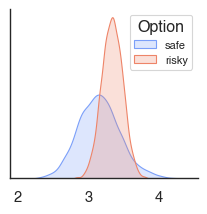

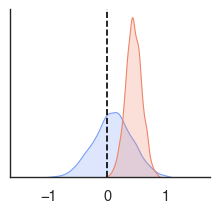

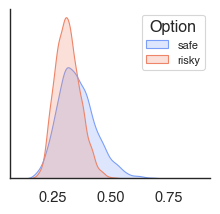

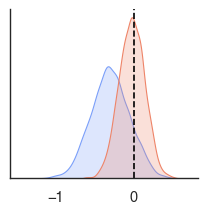

In [8]:
#plt.title('prior')
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.2, palette='tab10')

palette = sns.color_palette('coolwarm', 4)
palette = [palette[ix] for ix in [0, 3]]

for param in ['mu', 'std']:
    for regressor in ['Intercept' , 'session:group']:
        
        if param == 'std' and regressor == 'Intercept':
            val = 'value_softpl'
        else:
            val = 'value'
        prior_mus= pd.concat((idata.posterior[f'safe_prior_{param}_mu'].to_dataframe(), (idata.posterior[f'risky_prior_{param}_mu'].to_dataframe())), axis=1)
        prior_mus.columns.name = 'parameter'
        prior_mus.index = prior_mus.index.set_names(['chain','draw','regressor']) 
        prior_mus = prior_mus.stack().to_frame('value')
        prior_mus['Option'] = prior_mus.index.get_level_values('parameter').map({f'safe_prior_{param}_mu':'safe', f'risky_prior_{param}_mu':'risky'})
        prior_mus['value_softpl'] = softplus_np(prior_mus['value']) # for param == 'std' and regressor == 'Intercept'

        fac = sns.FacetGrid(prior_mus.xs(regressor, 0,'regressor').reset_index(), hue='Option', palette=palette, aspect=1.1, height=2.5)
        fac.map(sns.kdeplot, val, fill=True)
        fac.set(xlabel=None, ylabel=None, yticks=[])

        if regressor =='Intercept': 
            plt.legend(title='Option',loc='upper right',fontsize='x-small')
        #plt.title(f'{param}_{regressor}')
        
        if regressor =='session:group': 
            plt.axvline(0, c='black', ls='--')

        plt.savefig(op.join(plot_folder_path, f'NLC_model-1_prior_{param}_{regressor}.pdf'), bbox_inches='tight')


In [9]:
evidence_sd = pd.concat((idata.posterior['n1_evidence_sd_mu'].to_dataframe(), (idata.posterior['n2_evidence_sd_mu'].to_dataframe())), axis=1)
evidence_sd.columns.name = 'parameter'
evidence_sd.index = evidence_sd.index.set_names(['chain','draw','regressor']) # get handel on regressors #'subject',
evidence_sd = evidence_sd.stack().to_frame('value')
evidence_sd['Noise'] = evidence_sd.index.get_level_values('parameter').map({'n1_evidence_sd_mu':'1', 'n2_evidence_sd_mu':'2'})
evidence_sd['value_softpl'] = softplus_np(evidence_sd['value'])


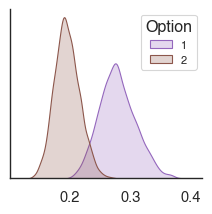

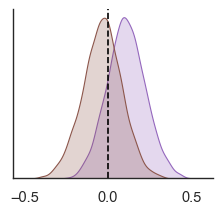

In [10]:
#plt.title('Evidence sd mu')
palette = sns.color_palette()[4:]
#palette = [palette[ix] for ix in [6,8]]

for regressor in ['Intercept' , 'session:group']:
    if regressor == 'Intercept':
        val = 'value_softpl'
    elif regressor =='session:group': 
        val = 'value'

    fac = sns.FacetGrid(evidence_sd.xs(regressor, 0,'regressor').reset_index(), hue='Noise', palette=palette, aspect=1.1, height=2.5)
    fac.map(sns.kdeplot, val, fill=True)
    fac.set(xlabel=None, ylabel=None, yticks=[])
    if regressor =='Intercept':
        plt.legend(title='Option',loc='upper right',fontsize='x-small')
    if regressor =='session:group': 
        plt.axvline(0, c='black', ls='--')

    #plt.xlim([0,0.5])
    plt.savefig(op.join(plot_folder_path, f'NLC_model-1_evidence_sd_{regressor}.pdf'), bbox_inches='tight')


## Decoding

In [3]:
# E_diff
Es_within = pd.read_csv(op.join(bids_folder, 'interim_sum_data', 'within_ses_decodedE.csv'))
Es_across = pd.read_csv(op.join(bids_folder, 'interim_sum_data','across_ses_decodedE.csv'))

Es_within = Es_within.set_index(['subject', 'trial_nr', 'session']).rename(mapper={'E':'E_w', 'sd':'sd_w'}, axis=1).xs(2,0,'session')
Es_across = Es_across.set_index(['subject', 'trial_nr']).rename(mapper={'E':'E_a', 'sd':'sd_a'}, axis=1)

from stress_risk.utils.data import add_cond2df
Es = Es_within.join(Es_across).set_index('risky_first', append=True)
Es = add_cond2df(Es)
Es['E_dif'] = Es['E_a'] - Es['E_w']

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


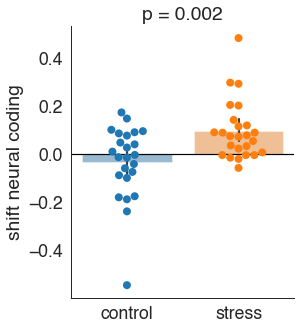

In [77]:
import pingouin
sns.set_theme('paper', 'white', font='helvetica', font_scale=2, palette='tab10')

temp = Es.groupby(['subject']).mean()
temp['group_name'] = np.where(temp['group'] == 0, 'control', 'stress')

#sns.catplot(data=temp.reset_index(), x='group_name', y='E_dif',  kind='bar') #kind='bar',,errorbar=get_hdi

plt.figure(figsize=(4, 5)) 
sns.barplot(data=temp.reset_index(), x='group_name', y='E_dif', alpha=0.5)
sns.swarmplot(data=temp.reset_index(), x='group_name', y='E_dif', size=8)

plt.xlabel(None)
plt.ylabel('shift neural coding')
an = pingouin.anova(data=temp.reset_index(), dv='E_dif', between='group')
p_val = np.round(an['p-unc'][0],3)
plt.title(f'p = {p_val}')
plt.axhline(0, c='black')
sns.despine()
plt.savefig(op.join(plot_folder_path, 'shift-neural-coding_swarm-bar-plot_groups.pdf'), bbox_inches='tight')

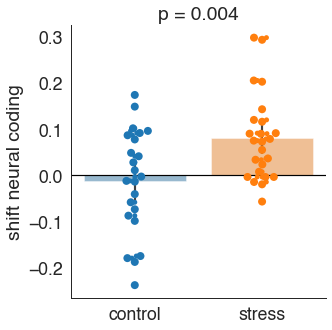

In [78]:
# outlier removed
max_val = temp['E_dif'].max()
min_val = temp['E_dif'].min()
filtered_temp = temp[(temp['E_dif'] != max_val) & (temp['E_dif'] != min_val)]

sns.catplot(data=filtered_temp.reset_index(), x='group_name', y='E_dif',  kind='swarm') #kind='bar',,errorbar=get_hdi

sns.barplot(data=filtered_temp.reset_index(), x='group_name', y='E_dif', alpha=0.5)
sns.swarmplot(data=filtered_temp.reset_index(), x='group_name', y='E_dif', size=8)

plt.xlabel(None)
plt.ylabel('shift neural coding')
an = pingouin.anova(data=filtered_temp.reset_index(), dv='E_dif', between='group')
p_val = np.round(an['p-unc'][0],3)
plt.title(f'p = {p_val}')
plt.axhline(0, c='black')

In [79]:
df_wdec = pd.read_csv(op.join(bids_folder, 'interim_sum_data','within-ses-decod_r-sds.csv'))
df_wdec = df_wdec.set_index(['group','subject','session'])

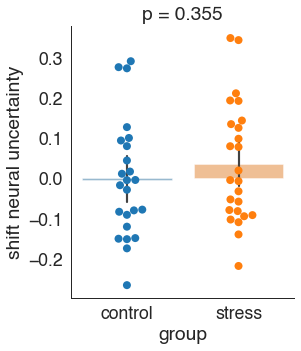

In [84]:
import pingouin
from matplotlib.ticker import FormatStrFormatter

y_var = 'r'
dd = df_wdec.xs(1,0,'session') - df_wdec.xs(2,0,'session')

plt.figure(figsize=(4, 5)) 
fac = sns.barplot(data=dd.reset_index(), x='group', y=y_var, alpha=0.5)
sns.swarmplot(ax=fac,data=dd.reset_index(), x='group', y=y_var,size=8)

plt.ylabel('shift neural uncertainty')
sns.despine()

an = pingouin.anova(data=dd.reset_index(), dv=y_var, between='group')
p_val = np.round(an['p-unc'][0],3)
plt.title(f'p = {p_val}')
plt.savefig(op.join(plot_folder_path, 'shift_decodability-r_catplot-groups.pdf'), bbox_inches='tight')

Text(0.5, 1.0, 'test-retest: sds \n r=0.32, p= 0.027 ')

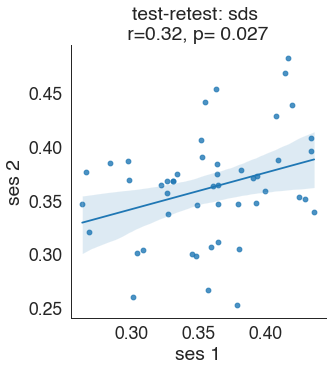

In [114]:
param = 'sds'
df1 = df_wdec.xs(1,0,'session')[param].to_frame()
df2 = df_wdec.xs(2,0,'session')[param].to_frame()

df1 = df1.rename(mapper={param : f'ses 1'},axis=1)
df2 = df2.rename(mapper={param : f'ses 2'},axis=1)

temp = pd.concat([df1,df2],axis=1)
fac = sns.lmplot(data=temp , x ='ses 1', y = 'ses 2') #, hue='group'
cor = pingouin.corr(temp['ses 1'], temp['ses 2'])
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 3)
plt.title(f'test-retest: {param} \n r={r_}, p= {p} ')

## AUC group difference

In [57]:
from stress_risk.analyse_results.utils import get_stress_level
df_stress_sr = pd.read_csv('/Users/mrenke/data/ds-stressrisk/addMeasures/selfRated_Stress.csv')
df_stress_sr_all = pd.read_csv('/Users/mrenke/data/ds-stressrisk/addMeasures/selfRated_Stress_allMeasures.csv')

stress_measure = 'mean_stress' #'auc_stress'
df_stress_sr = df_stress_sr_all.set_index(['subject','group'])[[stress_measure]]
#df_stress_sr.head()

In [58]:
df_stress_sr = df_stress_sr.rename(mapper={stress_measure:'self-rated_auc'}, axis=1)
df_auc = get_stress_level().rename(mapper={'AUC':'cortisol_auc'}, axis=1)

df_comb = df_auc.join(df_stress_sr.reset_index('group'))
df_comb['group'] = np.where( df_comb['group']== 0.0, 'control', 'stress')
df_comb = df_comb.set_index('group', append=True)
df_comb.head()

,,cortisol_auc,self-rated_auc
subject,group,,
1,control,2.060,6.981949
2,control,-0.505,2.843103
3,stress,3.530,7.110147
4,stress,1.055,7.074323
5,control,-0.635,2.557188


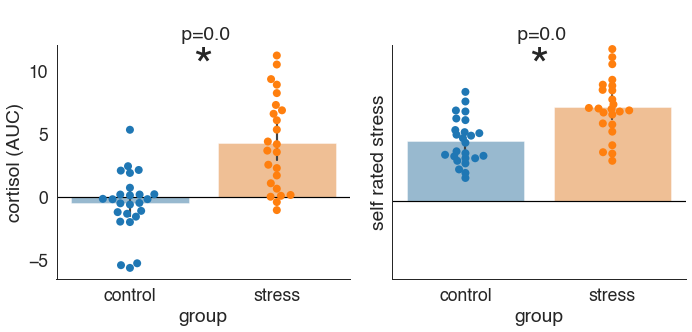

In [76]:
from scipy.stats import ttest_ind

col_names = ['cortisol_auc', 'self-rated_auc']

fig, axs = plt.subplots(1, 2, figsize=(10,5))

for ax, column in zip(axs, col_names):
    sns.barplot(ax=ax, data=df_comb.reset_index(), x='group', y=column, alpha=0.5)
    sns.swarmplot(ax=ax, data=df_comb.reset_index(), x='group', y=column, size=8)
    if column == 'self-rated_auc':
        ax.set_ylim([-5,10])
        ax.set_yticks([])
    ax.axhline(0, c='black')
    t_stat, p_val = ttest_ind(df_comb.xs('control',0,'group')[column], df_comb.xs('stress',0,'group')[column])
    ax.set_title(f'\n p={np.round(p_val,3)}') # {column} 
    if p_val < 0.05:
        ax.text(0.5, 0.8, '*', transform=ax.transAxes, ha='center', va='bottom',fontsize=50) 


axs[0].set_ylabel('cortisol (AUC)')
axs[1].set_ylabel('self rated stress')

plt.tight_layout()
sns.despine()
plt.savefig(op.join(plot_folder_path, 'stress_swarmplot.pdf'), bbox_inches='tight')

# Behav - Neural - corr.

### stress-effect: shift-prior with E-diff

In [86]:
len(Es.index.unique('subject')) # sub 1 is missing

49

In [5]:
# load in data frame from behavior/shifts_decode-priors.ipynb
df_comb_shifts = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/r-prior-shift_Ediff_AUC.csv')

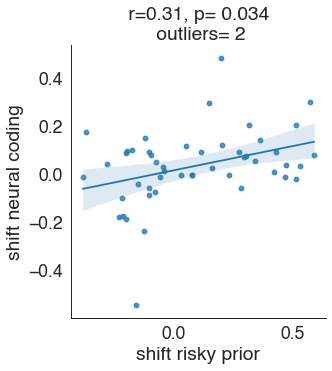

In [8]:
import pingouin
sns.set_theme('paper', 'white', font='helvetica', font_scale=2, palette='tab10')

name_prior = 'risky_prior'
method = 'shepherd' # = robust, N-outliers = 2

temp = df_comb_shifts
fac = sns.lmplot(data=temp.reset_index() , y = 'E_dif',x= f'{name_prior}_mu') #, hue='group'
cor = pingouin.corr(temp['E_dif'], temp[f'{name_prior}_mu'], method='shepherd')
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 3)
outliers = cor['outliers'][0]
fac.set(xlabel='shift risky prior',ylabel='shift neural coding', title = f' r={r_}, p= {p} \n outliers= {outliers}')
plt.savefig(op.join(plot_folder_path, 'shift-prior_E-diff_corr_robust.pdf'), bbox_inches='tight')

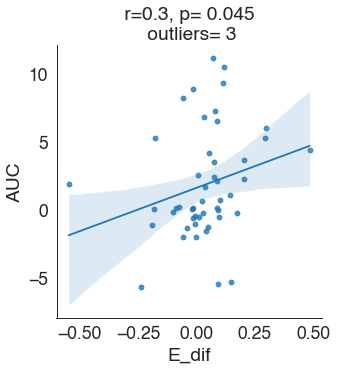

In [108]:

temp = df_comb_shifts

x_var = 'E_dif'# 'risky_prior_mu' #
fac = sns.lmplot(data=temp.reset_index() , x=x_var, y = 'AUC') 
cor = pingouin.corr(temp[x_var], temp[f'AUC'], method='shepherd')
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 3)
outliers = cor['outliers'][0]

fac.set(xlabel=x_var,ylabel='AUC', title = f' r={r_}, p= {p} \n outliers= {outliers}')
plt.savefig(op.join(plot_folder_path, f'shift-{x_var}_AUC_corr_robust.pdf'), bbox_inches='tight')


In [31]:
pingouin.corr(df_comb['E_dif'], df_comb[f'{name_prior}_mu'], method='shepherd')

,n,outliers,r,CI95%,p-val,power
shepherd,49,2,0.309551,"[0.02, 0.55]",0.034231,0.572408


### general: n2 evid. with r/neural uncertainty

In [38]:
n2s= pd.read_csv(op.join('/Users/mrenke/data/ds-stressrisk/interim_sum_data', 'subwise_seswise_n2_evidence_sd.csv'))
n1s= pd.read_csv(op.join('/Users/mrenke/data/ds-stressrisk/interim_sum_data', 'subwise_seswise_n1_evidence_sd.csv'))

df_ev_sd = n1s.set_index(['subject','session']).join(n2s.set_index(['subject','session']))


In [47]:
decod =  pd.read_csv(op.join('/Users/mrenke/data/ds-stressrisk/interim_sum_data','within-ses-decod_r-sds.csv'))
decod = decod.set_index(['subject','session'])

df_comb_int = df_ev_sd.join(decod)

In [90]:
df_comb_int.head()

,,n1_evidence_sd,n2_evidence_sd,group,sds,r
subject,session,,,,,
1,1,0.324216,0.153327,control,0.297518,0.038720
2,1,0.315138,0.224862,control,0.363510,-0.020221
5,1,0.330258,0.175523,control,0.357436,0.240643
9,1,0.326566,0.244093,control,0.349030,0.090306
10,1,0.316187,0.204378,control,0.327351,0.185421


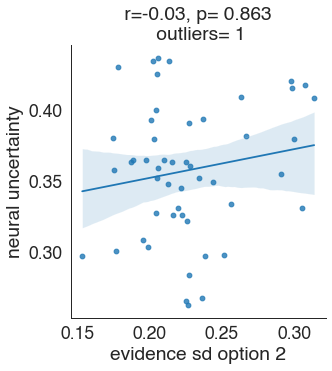

In [123]:
ses = 1#'both'
temp = df_comb_int.xs(ses,0,'session')

y_var ='n2_evidence_sd'
fac = sns.lmplot(data=temp.reset_index() , x =y_var, y = 'sds') #, hue='group',hue='session'
cor = pingouin.corr(temp[y_var], temp['sds'], method='shepherd')
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 3)
outliers = cor['outliers'][0]
fac.set(xlabel=f'evidence sd option {y_var[1]}',ylabel='neural uncertainty', title = f' r={r_}, p= {p} \n outliers= {outliers}')
plt.savefig(op.join(plot_folder_path, f'sds-{y_var}_ses-{ses}_corr_robust.pdf'), bbox_inches='tight')

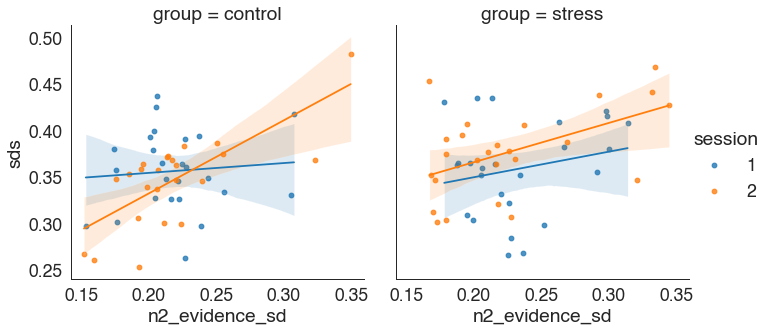

In [92]:
fac = sns.lmplot(data=df_comb_int.reset_index() , x =y_var, y = 'sds',hue='session',col='group') #, hue='group'


### check test-retest reliability 

Text(0.5, 1.0, 'test-retest: n2_evidence_sd')

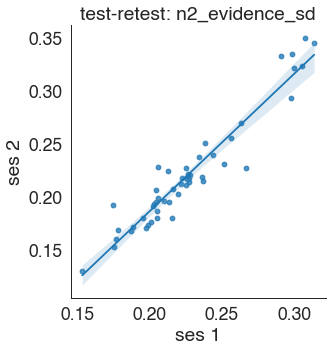

In [122]:
param = 'n2_evidence_sd'
df1 = df_comb_int.xs(1,0,'session')[param].to_frame()
df2 = df_comb_int.xs(2,0,'session')[param].to_frame()

df1 = df1.rename(mapper={param : f'ses 1'},axis=1)
df2 = df2.rename(mapper={param : f'ses 2'},axis=1)

temp = pd.concat([df1,df2],axis=1)
fac = sns.lmplot(data=temp , x ='ses 1', y = 'ses 2') #, hue='group'
plt.title(f'test-retest: {param}')

### AUC corr- 

In [ ]:
df_auc